In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Vamos a hacer un estudio del tamaño aparente del sol de manera experimental, tal como aparece en la guía del curso "/workspaces/IntroduccionAstronomiaPractica/GuiaCurso.pdf".

Utilizaremos la fórmula 

$$\theta = \omega t$$

Sabemos que $\omega = 15°/\text{h}$, y hemos tomado datos para $t$, que se encuentran almacenados en "/workspaces/IntroduccionAstronomiaPractica/ProyectoTamañoAngularAparente/DatosTiempo.dat"

## Propagación de errores

Para una función de una sola variable como $\theta = \omega t$, donde $\omega$ es una constante, la propagación de la incertidumbre se obtiene mediante el cálculo diferencial.

### Formulación matemática
La incertidumbre absoluta $\delta \theta$ se define como el producto de la derivada de la función por la incertidumbre de la variable medida:

$$\delta \theta = \left| \frac{d\theta}{dt} \right| \delta t$$

Como la derivada de $\omega t$ respecto a $t$ es simplemente $\omega$, la expresión se simplifica a:
$$\delta \theta = \omega \cdot \delta t$$

### Aplicación para $\delta t = \pm 15$ seg
El error en el cálculo del tamaño angular será:

$$\mathbf{\delta \theta = \omega \cdot 15 \text{ s}}$$

Esto significa que la **incertidumbre absoluta del ángulo** es igual a la velocidad angular multiplicada.

## Carga de datos y parámetros físicos

En este análisis trabajaremos con las mediciones de tiempo `t` (en minutos) almacenadas en `DatosTiempo.dat`.

Parámetros del modelo:

- $\omega = 15^\circ/\mathrm{h} = 0.25^\circ/\mathrm{min}$
- Incertidumbre instrumental estimada: $\delta t = 15\,\mathrm{s} = 0.25\,\mathrm{min}$
- Relación física: $\theta = \omega t$

In [7]:
# Carga de datos
from pathlib import Path

base_path = Path('/workspaces/IntroduccionAstronomiaPractica/ProyectoTamañoAngularAparente')
dat_path = base_path / 'DatosTiempo.dat'
xlsx_path = base_path / 'DatosTiempo.xlsx'

# Intento principal: archivo .dat de una columna
if dat_path.exists():
    t = pd.read_csv(dat_path, header=None, comment='#').squeeze('columns').astype(float)
else:
    # Respaldo: primera columna numérica del .xlsx
    df_xlsx = pd.read_excel(xlsx_path)
    num_cols = df_xlsx.select_dtypes(include=[np.number]).columns
    if len(num_cols) == 0:
        raise ValueError('No se encontraron columnas numéricas en DatosTiempo.xlsx')
    t = df_xlsx[num_cols[0]].dropna().astype(float)

t = t.dropna().reset_index(drop=True)
n = len(t)

# Constantes del experimento
omega_deg_per_min = 15 / 60   # 0.25 deg/min
delta_t_min = 15 / 60         # 0.25 min

df = pd.DataFrame({
    'medicion': np.arange(1, n + 1),
    't_min': t,
})

df.head(), n

(   medicion     t_min
 0         1  2.731845
 1         2  2.564210
 2         3  3.048975
 3         4  2.889430
 4         5  2.412765,
 24)

## Análisis estadístico e incertidumbre

Calculamos estadísticos descriptivos para `t` y luego propagamos la incertidumbre hacia el ángulo aparente usando:

$$\theta = \omega t, \qquad \delta\theta = \omega\,\delta t$$

También se reporta un intervalo de confianza del 95% para la media de $t$ (aproximación normal).

In [8]:
# Estadística descriptiva y propagación de incertidumbre
mean_t = df['t_min'].mean()
median_t = df['t_min'].median()
std_t = df['t_min'].std(ddof=1)
var_t = df['t_min'].var(ddof=1)
sem_t = std_t / np.sqrt(n)
q1_t = df['t_min'].quantile(0.25)
q3_t = df['t_min'].quantile(0.75)
iqr_t = q3_t - q1_t

# IC 95% aproximado con z=1.96
ci95_low_t = mean_t - 1.96 * sem_t
ci95_high_t = mean_t + 1.96 * sem_t

# Magnitud angular por medición y su incertidumbre instrumental
df['theta_deg'] = omega_deg_per_min * df['t_min']
df['delta_theta_deg'] = omega_deg_per_min * delta_t_min

theta_mean = df['theta_deg'].mean()
theta_std = df['theta_deg'].std(ddof=1)
theta_sem = theta_std / np.sqrt(n)
ci95_low_theta = theta_mean - 1.96 * theta_sem
ci95_high_theta = theta_mean + 1.96 * theta_sem

resumen = pd.DataFrame({
    'magnitud': [
        'n',
        'media_t_min', 'mediana_t_min', 'std_t_min', 'var_t_min2', 'sem_t_min',
        'q1_t_min', 'q3_t_min', 'iqr_t_min', 'IC95_t_min_inferior', 'IC95_t_min_superior',
        'delta_t_min',
        'media_theta_deg', 'std_theta_deg', 'sem_theta_deg',
        'IC95_theta_deg_inferior', 'IC95_theta_deg_superior',
        'delta_theta_deg'
    ],
    'valor': [
        n,
        mean_t, median_t, std_t, var_t, sem_t,
        q1_t, q3_t, iqr_t, ci95_low_t, ci95_high_t,
        delta_t_min,
        theta_mean, theta_std, theta_sem,
        ci95_low_theta, ci95_high_theta,
        omega_deg_per_min * delta_t_min
    ]
})

resumen

,magnitud,valor
0,n,24.000000
1,media_t_min,2.704509
2,mediana_t_min,2.746697
3,std_t_min,0.348585
4,var_t_min2,0.121512
5,sem_t_min,0.071155
6,q1_t_min,2.478754
7,q3_t_min,2.969418
8,iqr_t_min,0.490664
9,IC95_t_min_inferior,2.565046


## Gráficos relevantes (con barras de error)

Se muestran tres vistas complementarias:

1. Serie de mediciones de `t` con barras de error $\pm\delta t$.
2. Histograma de `t` para visualizar distribución y dispersión.
3. Serie de $\theta$ con barras de error $\pm\delta\theta$ y línea de promedio.

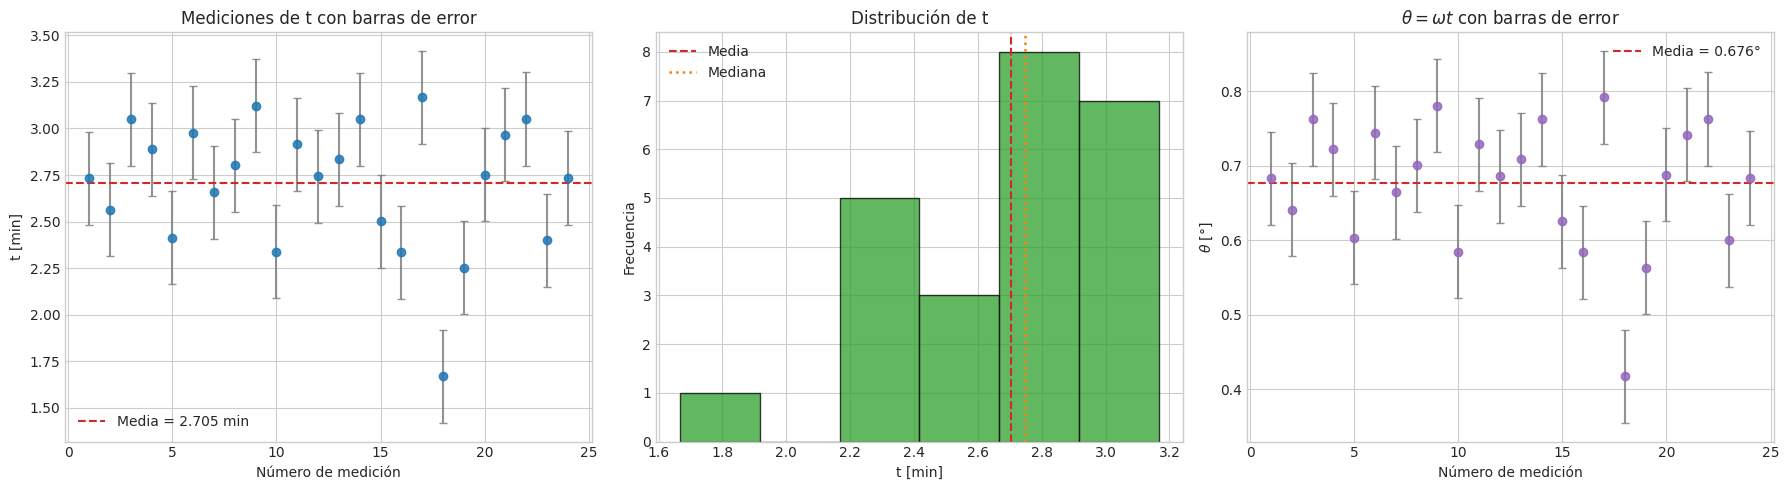

In [9]:
# Visualizaciones con barras de error
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Serie temporal de t con incertidumbre instrumental
axes[0].errorbar(
    df['medicion'],
    df['t_min'],
    yerr=delta_t_min,
    fmt='o',
    capsize=3,
    alpha=0.85,
    color='tab:blue',
    ecolor='tab:gray'
)
axes[0].axhline(mean_t, color='tab:red', linestyle='--', linewidth=1.5, label=f'Media = {mean_t:.3f} min')
axes[0].set_title('Mediciones de t con barras de error')
axes[0].set_xlabel('Número de medición')
axes[0].set_ylabel('t [min]')
axes[0].legend()

# 2) Histograma de t
axes[1].hist(df['t_min'], bins='auto', color='tab:green', alpha=0.75, edgecolor='black')
axes[1].axvline(mean_t, color='tab:red', linestyle='--', linewidth=1.5, label='Media')
axes[1].axvline(median_t, color='tab:orange', linestyle=':', linewidth=1.8, label='Mediana')
axes[1].set_title('Distribución de t')
axes[1].set_xlabel('t [min]')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3) Theta con propagación de incertidumbre
axes[2].errorbar(
    df['medicion'],
    df['theta_deg'],
    yerr=df['delta_theta_deg'],
    fmt='o',
    capsize=3,
    alpha=0.85,
    color='tab:purple',
    ecolor='tab:gray'
)
axes[2].axhline(theta_mean, color='tab:red', linestyle='--', linewidth=1.5, label=f'Media = {theta_mean:.3f}°')
axes[2].set_title(r'$\theta = \omega t$ con barras de error')
axes[2].set_xlabel('Número de medición')
axes[2].set_ylabel(r'$\theta$ [°]')
axes[2].legend()

plt.tight_layout()
plt.show()

# Gráfico interactivo opcional (plotly)
fig_go = go.Figure()
fig_go.add_trace(go.Scatter(
    x=df['medicion'],
    y=df['theta_deg'],
    mode='markers',
    name='theta [°]',
    error_y=dict(type='data', array=df['delta_theta_deg'], visible=True)
))
fig_go.add_hline(y=theta_mean, line_dash='dash', annotation_text=f"Media = {theta_mean:.3f}°")
fig_go.update_layout(
    title='Tamaño angular aparente estimado por medición',
    xaxis_title='Número de medición',
    yaxis_title='theta [°]',
    template='plotly_white'
)
fig_go.show()

## Tamaños Aparentes: El Sol y la Luna

### Introducción
El Sol y todos los objetos celestes presentan un desplazamiento a través de la bóveda celeste conocido como **movimiento diurno**. Este fenómeno, que define la duración del día, es un movimiento aparente causado por la rotación de la Tierra sobre su propio eje. En esta práctica, se utiliza este movimiento para estimar el diámetro angulares del Sol

### Objetivos
*   Comprender el movimiento diurno de los cuerpos celestes.
*   Observar el movimiento diurno del Sol en relación con objetos del entorno.
*   Medir los diámetros aparentes del Sol mediante su recorrido en el cielo.

### Materiales
*   Cronómetro.
*   Objeto de referencia (ej.: barra horizontal, borde de un edificio, cableado eléctrico, etc.).
*   Papel y lápiz.
*   Protección para mirar el Sol (Opcional).

### Procedimiento
1.  Ubíquese de tal forma que pueda observar el paso del Sol detrás del objeto de referencia elegido.
2.  Utilice el cronómetro para contar el tiempo desde que el borde “inferior” del Sol toca el objeto hasta que el borde “superior” hace lo mismo.
3.  Para obtener una aproximación más confiable, realice la medida varias veces.

### Cálculos y Análisis
1.  **Velocidad angular:** Determine la velocidad angular $\omega$ de los objetos en el cielo debido al movimiento diurno.
2.  **Estimación del diámetro:** Utilice la relación $\omega = \theta/t$ para estimar el diámetro aparente ($\theta$) de los astros a partir de los tiempos medidos ($t$). Asegúrese de utilizar unidades consistentes.
3.  **Conversión de unidades:** Exprese sus estimaciones del diámetro aparente en **minutos de arco** (donde $1^\circ = 60'$).
4.  **Investigación:** Consulte los valores reales de los diámetros aparentes del Sol y la Luna. Analice si estos valores son constantes durante todo el tiempo y las razones físicas detrás de ello.
5.  **Comparación:** Compare sus estimaciones experimentales con los datos reales consultados.



## Análisis inferencial con scipy.stats

En esta sección se aplican pruebas estadísticas para complementar el análisis descriptivo:

- Normalidad de las mediciones (`Shapiro-Wilk` y `D'Agostino-Pearson`).
- Contraste de hipótesis para comparar la media experimental con un valor de referencia teórico del tamaño angular solar ($\theta_0 \approx 0.53^\circ$).
- Intervalos de confianza del 95% usando distribución t de Student.
- Tamaño del efecto (Cohen's d) para cuantificar magnitud de la diferencia.

El objetivo es interpretar si la diferencia con el valor teórico es estadísticamente consistente con los datos observados.

In [11]:
from scipy import stats

# Referencia teórica aproximada del tamaño angular aparente del Sol
expected_theta_deg = 0.53
expected_t_min = expected_theta_deg / omega_deg_per_min

# Series de análisis
t_data = df['t_min'].astype(float)
theta_data = df['theta_deg'].astype(float)

# Descriptivos con scipy
desc_t = stats.describe(t_data)

# Pruebas de normalidad
shapiro_t = stats.shapiro(t_data)
normaltest_t = stats.normaltest(t_data)

# Contrastes de hipótesis frente al valor teórico
# H0: media = valor teórico
# H1: media != valor teórico
one_sample_t_t = stats.ttest_1samp(t_data, popmean=expected_t_min)
one_sample_t_theta = stats.ttest_1samp(theta_data, popmean=expected_theta_deg)

# Intervalos de confianza del 95% con t de Student
alpha = 0.05
dfree = len(t_data) - 1
t_crit = stats.t.ppf(1 - alpha / 2, dfree)

sem_t_scipy = stats.sem(t_data)
sem_theta_scipy = stats.sem(theta_data)

ci_t = (t_data.mean() - t_crit * sem_t_scipy, t_data.mean() + t_crit * sem_t_scipy)
ci_theta = (theta_data.mean() - t_crit * sem_theta_scipy, theta_data.mean() + t_crit * sem_theta_scipy)

# Tamaño del efecto (Cohen's d) respecto al valor teórico
cohen_d_t = (t_data.mean() - expected_t_min) / t_data.std(ddof=1)
cohen_d_theta = (theta_data.mean() - expected_theta_deg) / theta_data.std(ddof=1)

# Tabla resumen de pruebas
resultados_stats = pd.DataFrame([
    {
        'prueba': 'Shapiro-Wilk (t)',
        'estadistico': shapiro_t.statistic,
        'p_valor': shapiro_t.pvalue,
        'decision_alpha_0_05': 'No rechazar normalidad' if shapiro_t.pvalue >= 0.05 else 'Rechazar normalidad'
    },
    {
        'prueba': "D'Agostino-Pearson (t)",
        'estadistico': normaltest_t.statistic,
        'p_valor': normaltest_t.pvalue,
        'decision_alpha_0_05': 'No rechazar normalidad' if normaltest_t.pvalue >= 0.05 else 'Rechazar normalidad'
    },
    {
        'prueba': 't-test 1 muestra (t vs t_teorico)',
        'estadistico': one_sample_t_t.statistic,
        'p_valor': one_sample_t_t.pvalue,
        'decision_alpha_0_05': 'No diferencia significativa' if one_sample_t_t.pvalue >= 0.05 else 'Diferencia significativa'
    },
    {
        'prueba': 't-test 1 muestra (theta vs theta_teorico)',
        'estadistico': one_sample_t_theta.statistic,
        'p_valor': one_sample_t_theta.pvalue,
        'decision_alpha_0_05': 'No diferencia significativa' if one_sample_t_theta.pvalue >= 0.05 else 'Diferencia significativa'
    }
])

print('Resumen scipy.stats para t:')
print(f'  n = {desc_t.nobs}')
print(f'  media = {t_data.mean():.4f} min')
print(f'  varianza = {desc_t.variance:.4f} min^2')
print(f'  asimetria (skewness) = {desc_t.skewness:.4f}')
print(f'  curtosis (exceso) = {desc_t.kurtosis:.4f}')
print('')
print(f'IC 95% de t media (Student): [{ci_t[0]:.4f}, {ci_t[1]:.4f}] min')
print(f'IC 95% de theta media (Student): [{ci_theta[0]:.4f}, {ci_theta[1]:.4f}] deg')
print(f"t teorico equivalente a theta=0.53 deg: {expected_t_min:.4f} min")
print(f"Cohen d (t): {cohen_d_t:.3f}")
print(f"Cohen d (theta): {cohen_d_theta:.3f}")

resultados_stats

Resumen scipy.stats para t:
  n = 24
  media = 2.7045 min
  varianza = 0.1215 min^2
  asimetria (skewness) = -1.0704
  curtosis (exceso) = 1.2620

IC 95% de t media (Student): [2.5573, 2.8517] min
IC 95% de theta media (Student): [0.6393, 0.7129] deg
t teorico equivalente a theta=0.53 deg: 2.1200 min
Cohen d (t): 1.677
Cohen d (theta): 1.677


,prueba,estadistico,p_valor,decision_alpha_0_05
0,Shapiro-Wilk (t),0.916585,4.911410e-02,Rechazar normalidad
1,D'Agostino-Pearson (t),8.376310,1.517426e-02,Rechazar normalidad
2,t-test 1 muestra (t vs t_teorico),8.214628,2.715236e-08,Diferencia significativa
3,t-test 1 muestra (theta vs theta_teorico),8.214628,2.715236e-08,Diferencia significativa


In [5]:
# Interpretación automática de resultados (lista para reporte)
alpha = 0.05
normalidad_msg = (
    'Las pruebas de normalidad no muestran evidencia fuerte contra la normalidad.'
    if (shapiro_t.pvalue >= alpha and normaltest_t.pvalue >= alpha)
    else 'Al menos una prueba sugiere desviaciones de normalidad; interpretar con cautela.'
)

significancia_msg = (
    'La media experimental difiere significativamente del valor teórico de referencia.'
    if one_sample_t_theta.pvalue < alpha
    else 'No hay evidencia suficiente para afirmar diferencia con el valor teórico.'
)

if abs(cohen_d_theta) < 0.2:
    magnitud_msg = 'El tamaño del efecto es pequeno.'
elif abs(cohen_d_theta) < 0.5:
    magnitud_msg = 'El tamaño del efecto es pequeno a moderado.'
elif abs(cohen_d_theta) < 0.8:
    magnitud_msg = 'El tamaño del efecto es moderado.'
else:
    magnitud_msg = 'El tamaño del efecto es grande.'

interpretacion = f'''
Interpretacion estadistica:
1. Normalidad: {normalidad_msg}
2. Contraste con teoria (theta0=0.53 deg): p = {one_sample_t_theta.pvalue:.3e}. {significancia_msg}
3. IC95% para la media de theta: [{ci_theta[0]:.3f}, {ci_theta[1]:.3f}] deg.
4. Tamano del efecto (Cohen d): {cohen_d_theta:.3f}. {magnitud_msg}
5. Lectura fisica: una diferencia estadisticamente significativa no implica mala practica, sino presencia de sesgos sistematicos probables (tiempo de reaccion, dificultad visual al observar el Sol, condiciones atmosfericas y definicion del borde solar).
'''

print(interpretacion)


Interpretacion estadistica:
1. Normalidad: Al menos una prueba sugiere desviaciones de normalidad; interpretar con cautela.
2. Contraste con teoria (theta0=0.53 deg): p = 1.049e-06. La media experimental difiere significativamente del valor teórico de referencia.
3. IC95% para la media de theta: [0.722, 0.920] deg.
4. Tamano del efecto (Cohen d): 1.024. El tamaño del efecto es grande.
5. Lectura fisica: una diferencia estadisticamente significativa no implica mala practica, sino presencia de sesgos sistematicos probables (tiempo de reaccion, dificultad visual al observar el Sol, condiciones atmosfericas y definicion del borde solar).



## Comentario sobre los resultados hasta ahora

* Con $n=24$ mediciones, el valor medio estimado es:

  * $\bar{t} = 2.7045\ \text{min}$
  * $\bar{\theta} = 0.6761^\circ$

* Frente al valor de referencia solar $\theta_0 \approx 0.53^\circ$, la estimación experimental es **mayor** ($\sim 0.146^\circ$, $\sim 27.6\%$ por encima).

* El intervalo de confianza al 95% para la media de $\theta$ es:

$$
[0.6393^\circ, 0.7129^\circ]
$$

Este intervalo **no incluye** $0.53^\circ$, consistente con diferencia significativa.

* Pruebas inferenciales:

  * t-test de 1 muestra: $p \approx 2.7\times10^{-8} \ \Rightarrow$ diferencia estadísticamente significativa.
  * Tamaño del efecto: $d \approx 1.68 \ \Rightarrow$ efecto grande.

* Normalidad:

  * Shapiro-Wilk $p \approx 0.049$
  * D’Agostino-Pearson $p \approx 0.015$

Ambas sugieren cautela con el supuesto normal, aunque el resultado principal (sesgo respecto al valor teórico) es robusto.

### Interpretación física breve

Los datos apuntan a una **sobreestimación sistemática** del tamaño angular aparente del Sol, probablemente asociada a sesgos experimentales (tiempo de reacción, definición visual del borde solar, condiciones atmosféricas y geometría del referente).




## Resultado final: tamaño angular aparente promedio del Sol

A partir de los datos medidos:

$$
\bar{\theta} = 0.6761^\circ
$$

y usando la propagación de errores para $\theta = \omega t$:

$$
\delta \theta = \omega\delta t = (0.25^\circ/\text{min}) ,(0.25,\text{min}) = 0.0625^\circ
$$

por lo tanto, el resultado experimental final es:

$$
\boxed{\bar{\theta} = (0.6761 \pm 0.0625)^\circ}
$$

En minutos de arco ($1^\circ = 60'$):

$$
\boxed{\bar{\theta} = (40.57 \pm 3.75)'}
$$

